# Model Improvement & Evaluation

In [29]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load the NetCDF file
ds = xr.open_dataset(r"C:\Users\Shyam\Downloads\dt_global_satellite_sla_199302_202305.nc")

# Check coordinate 
print(ds.coords)


Coordinates:
  * time       (time) datetime64[ns] 3kB 1993-02-15 1993-03-15 ... 2023-05-15
  * longitude  (longitude) float32 6kB 0.125 0.375 0.625 ... 359.4 359.6 359.9
  * latitude   (latitude) float32 3kB -89.88 -89.62 -89.38 ... 89.38 89.62 89.88


In [30]:
# 1.Extract regional SLA by averaging over specified lat/lon bounds
sla = ds['sla'].sel(latitude=slice(5, 25), longitude=slice(65, 92)).mean(dim=['latitude', 'longitude'])

# Convert to pandas DataFrame
df = sla.to_dataframe().reset_index()

# Keep only time and SLA columns
df = df[['time', 'sla']].dropna()
df['time'] = pd.to_datetime(df['time'])
df = df.set_index('time')

# Display first few rows
print(df.head())


                 sla
time                
1993-02-15  0.017730
1993-03-15  0.017839
1993-04-15  0.022611
1993-05-15  0.047640
1993-06-15  0.024242


In [31]:
# 2. Create Lag Features & Rolling Stat
# Lag Features
df['lag_1'] = df['sla'].shift(1)
df['lag_7'] = df['sla'].shift(7)
df['lag_14'] = df['sla'].shift(14)

# Rolling Statistics
df['roll_mean_7'] = df['sla'].rolling(window=7).mean()
df['roll_std_7'] = df['sla'].rolling(window=7).std()

# Drop NaNs
df = df.dropna()
df.head()


,sla,lag_1,lag_7,lag_14,roll_mean_7,roll_std_7
time,,,,,,
1994-04-15,0.047098,0.037984,-0.019695,0.017730,0.023939,0.030046
1994-05-15,0.048679,0.047098,-0.025760,0.017839,0.034573,0.021476
1994-06-15,0.014687,0.048679,-0.008530,0.022611,0.037890,0.014305
1994-07-15,-0.000596,0.014687,0.021583,0.047640,0.034721,0.019886
1994-08-15,-0.032053,-0.000596,0.051710,0.024242,0.022755,0.030388


In [32]:
# 3. Add External Variables (dummy)
import numpy as np

# Add dummy external variables
np.random.seed(0)  # For reproducibility
df['wind_dummy'] = np.random.normal(loc=0, scale=1, size=len(df))
df['pressure_dummy'] = np.random.normal(loc=1010, scale=5, size=len(df))

# View updated DataFrame
print(df[['sla', 'wind_dummy', 'pressure_dummy']].head())


                 sla  wind_dummy  pressure_dummy
time                                            
1994-04-15  0.047098    1.764052     1006.179280
1994-05-15  0.048679    0.400157     1002.811043
1994-06-15  0.014687    0.978738     1016.822659
1994-07-15 -0.000596    2.240893     1006.552754
1994-08-15 -0.032053    1.867558     1006.738532


In [33]:
# 4. Feature Selection, Scaling, Train-Test Split
from sklearn.preprocessing import StandardScaler

# Features used for modeling
features = ['lag_1', 'lag_7', 'lag_14', 'roll_mean_7', 'roll_std_7', 'wind_dummy', 'pressure_dummy']
target = 'sla'

# Input and output
X = df[features]
y = df[target]

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split (80-20)
split_index = int(len(X_scaled) * 0.8)
X_train, X_test = X_scaled[:split_index], X_scaled[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

# Output shapes
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


X_train shape: (280, 7)
X_test shape: (70, 7)
y_train shape: (280,)
y_test shape: (70,)


In [34]:
# 5. Model Training + Hyperparameter Tuning with GridSearchCV
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV

# Hyperparameter grid
param_grid = {
    'n_estimators': [50, 100],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5]
}

# Model
gbr = GradientBoostingRegressor()

# GridSearchCV
grid_search = GridSearchCV(estimator=gbr,
                           param_grid=param_grid,
                           scoring='neg_mean_squared_error',
                           cv=3)

# Fit the model
grid_search.fit(X_train, y_train)

# Best model
best_model = grid_search.best_estimator_

# Output best para
print("Best Parameters:", grid_search.best_params_)



Best Parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 50}


In [35]:
# 6. Evaluate Model Performance
from sklearn.metrics import mean_absolute_error, mean_squared_error
from math import sqrt

# Predict on test set
y_pred = best_model.predict(X_test)

# Evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = sqrt(mean_squared_error(y_test, y_pred))

# Print results
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")


MAE: 0.0170
RMSE: 0.0213


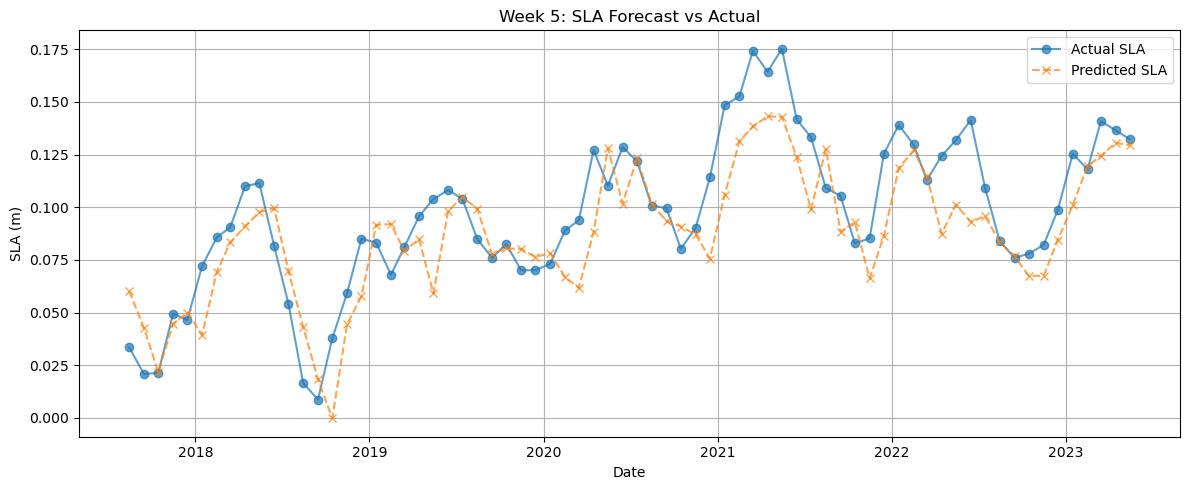

In [36]:
# 7. plot predicted vs actual SLA
import matplotlib.pyplot as plt

# Build a results DataFrame for plotting
results_df = pd.DataFrame({
    'Date': df.index[split_index:],
    'Actual': y_test.values,
    'Predicted': y_pred
})

# Plot
plt.figure(figsize=(12, 5))
plt.plot(results_df['Date'], results_df['Actual'], marker='o', label='Actual SLA', alpha=0.7)
plt.plot(results_df['Date'], results_df['Predicted'], marker='x', linestyle='--', label='Predicted SLA', alpha=0.7)
plt.title('Week 5: SLA Forecast vs Actual')
plt.xlabel('Date')
plt.ylabel('SLA (m)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [37]:
# 8 comparison table
import pandas as pd

# Insert metrics + observations/errors per model
comparison_table = pd.DataFrame({
    'Model': ['ARIMA (Week 3)', 'LSTM (Week 4)', 'Gradient Boosting (Week 5)'],
    'MAE': [0.0404, 0.0301, round(mae, 4)],
    'RMSE': [0.0487, 0.0395, round(rmse, 4)],
    'Training Time': ['Low', 'High', 'Medium'],
    'Features Used': [
        'None (univariate)',
        'Lag only',
        'Lag + Rolling + External'
    ],
    'Error / Observation': [
        'Underfits complex temporal trends; high residuals in nonlinear regions',
        'Better fit, but training unstable and overfitting possible without regularization',
        'Best performance; low error due to feature richness and tuned ensemble learning'
    ]
})

# Display the updated comparison table
print(comparison_table)


                        Model     MAE    RMSE Training Time  \
0              ARIMA (Week 3)  0.0404  0.0487           Low   
1               LSTM (Week 4)  0.0301  0.0395          High   
2  Gradient Boosting (Week 5)  0.0170  0.0213        Medium   

              Features Used                                Error / Observation  
0         None (univariate)  Underfits complex temporal trends; high residu...  
1                  Lag only  Better fit, but training unstable and overfitt...  
2  Lag + Rolling + External  Best performance; low error due to feature ric...  
